In [1]:
from arcgis.geometry import Geometry
from arcgis.mapping import create_symbol
import time

MapView(layout=Layout(height='400px', width='100%'))


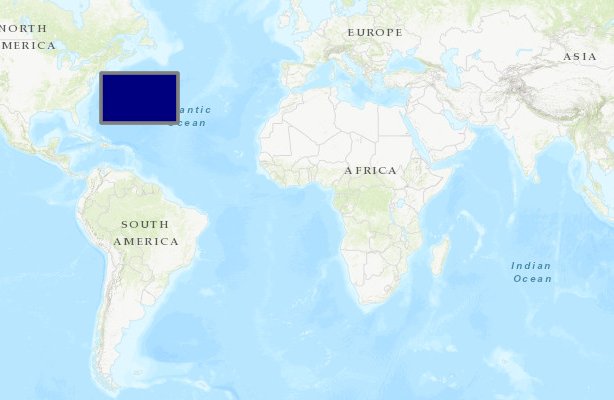

In [2]:
from arcgis.gis import GIS
gis = GIS()
map = gis.map()
map

In [3]:
geom = Geometry({'spatialReference': {'latestWkid': 4326,
       'wkid': 4326},
      'rings': [[[-72.48642904188986, 26.14669683070787],
        [-72.48642904188986, 40.73987910899463],
        [-45.50400716689704, 40.73987910899463],
        [-45.50400716689704, 26.14669683070787],
        [-72.48642904188986, 26.14669683070787]]]})
symbol = create_symbol(geometry_type='polygon', cstep=0)

In [4]:
map.draw(geom, symbol=symbol)

In [5]:
time.sleep(10)


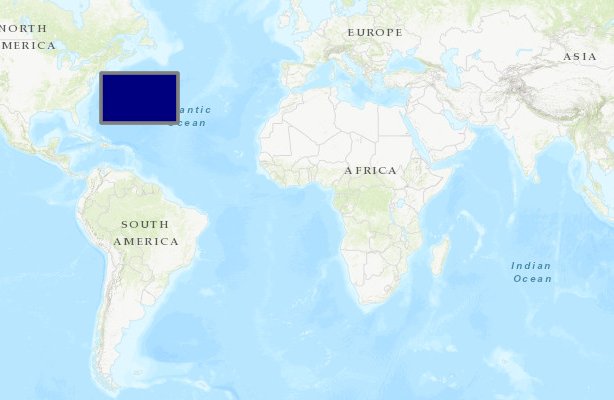

In [6]:
map.take_screenshot(file_path="./out2.png")

In [7]:
import sys

from scipy.misc import imread
from scipy.linalg import norm
from scipy import sum, average

def compare_images(img1, img2):
    # normalize to compensate for exposure difference, this may be unnecessary
    # consider disabling it
    img1 = normalize(img1)
    img2 = normalize(img2)
    # calculate the difference and its norms
    diff = img1 - img2  # elementwise for scipy arrays
    m_norm = sum(abs(diff))  # Manhattan norm
    z_norm = norm(diff.ravel(), 0)  # Zero norm
    return (m_norm, z_norm)

def to_grayscale(arr):
    "If arr is a color image (3D array), convert it to grayscale (2D array)."
    if len(arr.shape) == 3:
        return average(arr, -1)  # average over the last axis (color channels)
    else:
        return arr

def normalize(arr):
    rng = arr.max()-arr.min()
    amin = arr.min()
    return (arr-amin)*255/rng

In [10]:
img1 = to_grayscale(imread("out.png").astype(float))
img2 = to_grayscale(imread("out2.png").astype(float))
# compare
n_m, n_0 = compare_images(img1, img2)
print("Manhattan norm:", n_m, "/ per pixel:", n_m/img1.size)
print("Zero norm:", n_0, "/ per pixel:", n_0*1.0/img1.size)

/Users/davi9349/anaconda3/envs/geosaurus_dev_env/lib/python3.6/site-packages/ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.


OSError: cannot identify image file 'out.png'

In [9]:
!ls -la

total 16880
drwxr-xr-x  17 davi9349  AVWORLD\Domain Users      544 May 29 16:08 .
drwxr-xr-x  21 davi9349  AVWORLD\Domain Users      672 May 15 10:05 ..
drwxr-xr-x   9 davi9349  AVWORLD\Domain Users      288 May 29 15:38 .ipynb_checkpoints
-rw-r--r--   1 davi9349  AVWORLD\Domain Users     1634 Sep 27  2018 ClearGraphics.ipynb
-rw-r--r--   1 davi9349  AVWORLD\Domain Users     3253 Dec 12 08:37 ClearGraphicsTwice.ipynb
-rw-r--r--   1 davi9349  AVWORLD\Domain Users  1357266 Sep 27  2018 DrawPolygonAfterDisplay.ipynb
-rw-r--r--   1 davi9349  AVWORLD\Domain Users  1357180 Sep 27  2018 DrawPolygonBeforeDisplay.ipynb
-rw-r--r--   1 davi9349  AVWORLD\Domain Users   601379 Sep 27  2018 FeatureSetOfPoints.ipynb
-rw-r--r--   1 davi9349  AVWORLD\Domain Users   579206 Sep 27  2018 GeocodeDraw.ipynb
-rw-r--r--   1 davi9349  AVWORLD\Domain Users   470863 Jan  9 10:17 InteractiveDraw.ipynb
-rw-r--r--   1 davi9349  AVWORLD\Domain Users  1319855 May 29 15:35 PolygonCustomSymbology.ipynb
-rw-r--r--   1 d